In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
buffer_size = 8
x = torch.randn((buffer_size,))
x

tensor([ 0.8980,  0.2602, -0.8853, -0.3496,  0.4048, -0.3348, -1.4967, -0.9189])

In [5]:
X = torch.fft.fft(x)
x_again = torch.fft.ifft(X)
X, x_again

(tensor([-2.4223+0.0000j,  0.5115-1.4347j,  3.6848-1.1939j,  0.4750-0.2118j,
          0.2640+0.0000j,  0.4750+0.2118j,  3.6848+1.1939j,  0.5115+1.4347j]),
 tensor([ 0.8980+0.j,  0.2602+0.j, -0.8853+0.j, -0.3496+0.j,  0.4048+0.j, -0.3348+0.j,
         -1.4967+0.j, -0.9189+0.j]))

In [14]:
stft_x = torch.stft(x, n_fft=4, hop_length=2, return_complex=True)
stft_x, torch.istft(stft_x, n_fft=4, hop_length=2)

(tensor([[ 0.5332+0.0000j, -0.0767+0.0000j, -1.1649+0.0000j, -2.3456+0.0000j,
          -4.2471+0.0000j],
         [-1.7833+0.0000j,  1.7833-0.6098j, -1.2901+0.0148j,  1.9015-0.5840j,
           0.0000+0.5840j],
         [-0.5076+0.0000j,  0.1022+0.0000j,  0.2040+0.0000j,  0.1618+0.0000j,
          -1.7397+0.0000j]]),
 tensor([ 0.8980,  0.2602, -0.8853, -0.3496,  0.4048, -0.3348, -1.4967, -0.9189]))

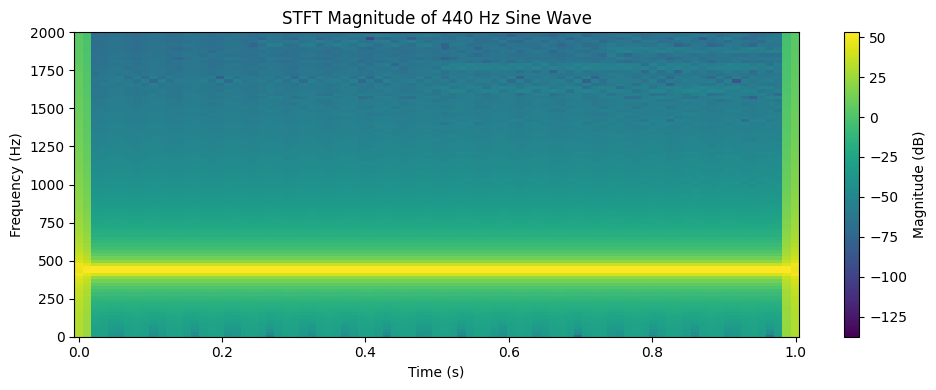

In [ ]:
sample_rate = 44_100
duration = 1.0
frequency = 440.0

num_samples = int(sample_rate * duration)
t = torch.arange(num_samples) / sample_rate
sin_wave = torch.sin(2 * torch.pi * frequency * t)

n_fft = 2048
hop_length = 512
window = torch.hann_window(n_fft)
stft_sine = torch.stft(
    sin_wave,
    n_fft=n_fft,
    hop_length=hop_length,
    window=window,
    return_complex=True,
)

magnitude_db = 20 * torch.log10(torch.abs(stft_sine) + 1e-8)
frequencies = torch.fft.rfftfreq(n_fft, d=1 / sample_rate)
times = torch.arange(stft_sine.shape[-1]) * hop_length / sample_rate

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.pcolormesh(times.numpy(), frequencies.numpy(), magnitude_db.numpy(), shading="auto")
plt.colorbar(label="Magnitude (dB)")
plt.title("STFT Magnitude of 440 Hz Sine Wave")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, 2000)
plt.tight_layout()